# Correcting for Template Changes in ATLAS Light Curves

This notebook takes into account ATLAS's periodic replacement of the difference image reference templates, which may cause step discontinuities in flux. Two template changes have been recorded at MJDs 58417 and 58882. More information can be found here: https://fallingstar-data.com/forcedphot/faq/.

We aid the user in adding offset flux to different regions of the ATLAS light curve in order to correct for these step discontinuities.

In order for this notebook to work correctly, the ATLAS light curves must already be downloaded and saved in ATClean-readable format. To download SN and control light curves in ATClean-readable format, please refer to the documentation `README.md` and use the download script `download.py`.

## Settings

<div class="alert alert-block alert-info">
    <b>Tip:</b> Edit the following settings to correspond to your target SN and source directory for data.
</div>


Below we have set example fields for SN 2018gkr. Recommended fields to change at a minimum include `TNSNAME`, `INPUT_DIR`, and `DISCOVERY_DATE`.

In [1]:
# ==== User Settings ====

# Enter the target SN name:
TNSNAME = '2018gkr'

# Enter the path to the data directory that contains the SN directories:
INPUT_DIR = f'/Users/sofiarest/Desktop/Supernovae/data_refactor/atclean_input' 

# Enter the path to a directory to optionally save any plots:
PLOTS_DIR = f'/Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/{TNSNAME}/plots'

# Enter the filter for this light curve:
FILT = 'o'

# Enter the SN's discovery date:
DISCOVERY_DATE = 58207.146991

# =======================

## Load the SN ATLAS light curve

In [2]:
import sys
sys.path.insert(1,'../')
from lightcurve import LightCurve, PresetColumnNames
from plot import Plot, PlotLimits
from download import load_config
from utils import reformat_dir, load_preset_column_names_from_config

INPUT_DIR = reformat_dir(INPUT_DIR, TNSNAME)

print(f'SN {TNSNAME}, filter {FILT}')
if not DISCOVERY_DATE is None:
    print(f'SN discovery date: {DISCOVERY_DATE}')
print(f'Source directory (load SN light curve): {INPUT_DIR}/{TNSNAME}')
print(f'Plots directory (save plots): {PLOTS_DIR}')
print(f'Config file path: ./config.ini')

SN 2018gkr, filter o
SN discovery date: 58207.146991
Source directory (load SN light curve): /Users/sofiarest/Desktop/Supernovae/data_refactor/atclean_input/2018gkr
Plots directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2018gkr/plots
Config file path: ./config.ini


In [3]:
# load config
config = load_config('config.ini')

# load preset
colnames = load_preset_column_names_from_config("atlas", config, filts=FILT)

print("\nLoading SN light curve...")
lc = LightCurve(colnames)
lc.load_lc(INPUT_DIR, TNSNAME, cleaned=False)
lc._clear_flux_offset_column()
print("Success")

p = Plot(PLOTS_DIR)


🔄 Loading config file at config.ini
✅ Success

🔄 Loading 'atlas' preset column names from config.ini
✅ Success
-- Required Columns --
mjd: MJD
flux: uJy
dflux: duJy
-- Optional Columns --
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
zpt: None
-- Extra Columns to Copy --
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs

Loading SN light curve...
Setting current flux offset to 0
Success

🔧 Using default color scheme for plots


# View the light curve before template correction

            MJD       m     dm  uJy  duJy  F  err  chi/N         RA      Dec        x        y   maj   min   phi  apfit  mag5sig    Sky             Obs  uJy_offset
0  57319.574461 -17.505  0.109 -361    39  o    0   1.00  124.36008  10.2028  5641.61    75.94  5.76  3.30   1.4 -0.463    18.89  20.46  02a57319o0575o           0
1  57319.587246 -17.642  0.089 -318    28  o    0   1.23  124.36008  10.2028  2159.77  9701.10  4.64  3.49 -59.0 -0.468    18.92  20.48  02a57319o0592o           0
2  57319.600039 -17.057  0.063 -546    34  o    0   1.30  124.36008  10.2028  5639.53    82.07  5.78  3.35   1.3 -0.455    18.94  20.53  02a57319o0609o           0
3  57319.611943 -17.576  0.087 -338    30  o    0   0.83  124.36008  10.2028  2156.75  9708.30  4.58  3.50 -59.9 -0.476    18.95  20.51  02a57319o0625o           0
4  57319.636298 -17.899  0.112 -251    28  o    0   0.92  124.36008  10.2028  3641.88  8254.70  4.07  3.08 -71.0 -0.462    18.97  20.51  02a57319o0657o           0
💾 Saving plot: /

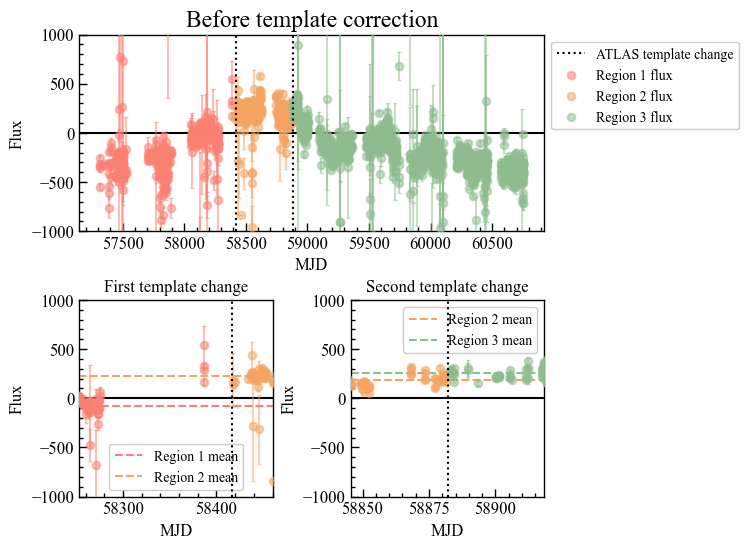

In [4]:
# ==== User Settings ====

# Optionally, manually enter the x and y limits for the plot:
xlim_lower = None
xlim_upper = None
ylim_lower = -1000
ylim_upper = 1000

# =======================

custom_lims = PlotLimits(
    xlower=xlim_lower,
    xupper=xlim_upper,
    ylower=ylim_lower,
    yupper=ylim_upper,
)

print(lc.t.head().to_string())

fig = p.plot_template_correction(
    lc, 
    custom_lims=custom_lims, 
    title="Before template correction", 
    save=True, 
    filename="before_template_correction"
)

# Apply template correction and view results

Proceeding with automatic template correction
Subtracting previous offset from flux column
Setting current flux offset to 0
Corrective flux 308.00 uJy added to region 1
Corrective flux 74.00 uJy added to region 3
Corrective flux 321.00 uJy added to region global

             MJD  uJy  uJy_offset  duJy
0  57319.574461  268         629    39
1  57319.587246  311         629    28
2  57319.600039   83         629    34
3  57319.611943  291         629    30
4  57319.636298  378         629    28
💾 Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2018gkr/plots/after_template_correction.png


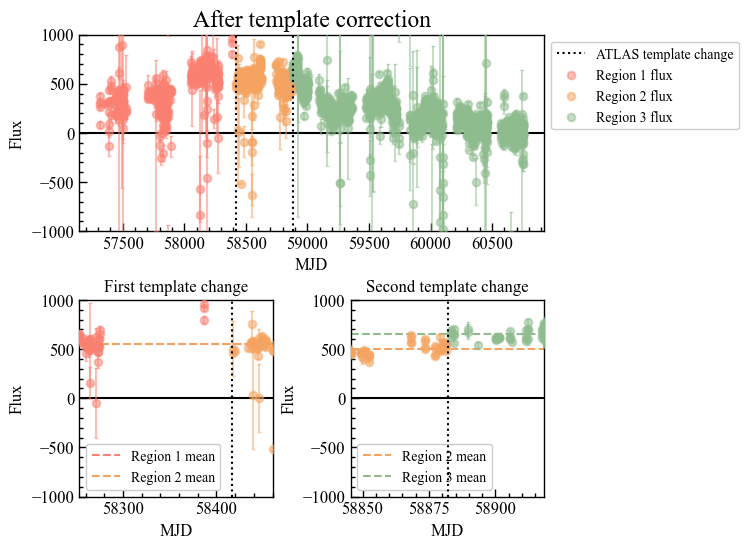

In [5]:
# ==== User Settings ====

# Optionally enter flux offsets for each region 
# (set each to None for automatic correction):
global_offset = None #5
region1_offset = None #0 + global_offset
region2_offset = None #-250 + global_offset
region3_offset = None #-250 + global_offset

# Optionally, manually enter the x and y limits for the plot:
xlim_lower = None
xlim_upper = None
ylim_lower = -1000
ylim_upper = 1000

# =======================

output = lc.apply_template_correction(
    DISCOVERY_DATE, 
    maskval=0x1|0x2|0x400000|0x800000, 
    region1_offset=region1_offset, 
    region2_offset=region2_offset, 
    region3_offset=region3_offset
)

print('\n'.join(output))
print('\n',lc.t[['MJD','uJy','uJy_offset','duJy']].head().to_string())

custom_lims = PlotLimits(
    xlower=xlim_lower,
    xupper=xlim_upper,
    ylower=ylim_lower,
    yupper=ylim_upper,
)

fig = p.plot_template_correction(
    lc, 
    custom_lims=custom_lims, 
    title="After template correction", 
    save=True, 
    filename="after_template_correction"
)